In [2]:
#import the essential libraries
import pandas as pd
import numpy as np
import pyodbc
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import f_oneway
from scipy.stats import ttest_ind

import statsmodels.formula.api as smf

In [3]:
# Load all datasets
orders = pd.read_csv('Olist/olist_orders_dataset.csv')
products = pd.read_csv('Olist/olist_products_dataset.csv')
order_items = pd.read_csv('Olist/olist_order_items_dataset.csv')
payments = pd.read_csv('Olist/olist_order_payments_dataset.csv')
reviews = pd.read_csv('Olist/olist_order_reviews_dataset.csv')
sellers = pd.read_csv('Olist/olist_sellers_dataset.csv')
translation = pd.read_csv('Olist/product_category_name_translation.csv')
customers = pd.read_csv('Olist/olist_customers_dataset.csv')
geolocation = pd.read_csv('Olist/olist_geolocation_dataset.csv')

In [4]:
# Dataset Information
datasets = {
    'orders': orders,
    'products': products,
    'order_items': order_items,
    'payments': payments,
    'reviews': reviews,
    'sellers': sellers,
    'translation': translation,
    'customers': customers,
    'geolocation': geolocation
}

for name, df in datasets.items():
    print(f'\n {name.upper()} DATASET ')
    print(df.head())
    print('\nShape:', df.shape)
    print('\nMissing Values:\n', df.isnull().sum())
    print('\nDuplicate Rows:', df.duplicated().sum())


 ORDERS DATASET 
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp order_approved_at  \
0    delivered         02-10-2017 10:56  02-10-2017 11:07   
1    delivered         24-07-2018 20:41  26-07-2018 03:24   
2    delivered         08-08-2018 08:38  08-08-2018 08:55   
3    delivered         18-11-2017 19:28  18-11-2017 19:45   
4    delivered         13-02-2018 21:18  13-02-2018 22:20   

  order_delivered_carrier_date order_delivered_customer_date  \
0             04-10-2017 19:55              10-10-2017 21:25   
1             26-07-2018 14:31              07-0

In [5]:
# Orders dataset

# Converting dates to datetime format
order_date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in order_date_cols:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

# Removing duplicates from dataset
orders.drop_duplicates(inplace=True)

# Fill missing approved dates with purchase timestamp
orders['order_approved_at'].fillna(orders['order_purchase_timestamp'], inplace=True)

# Fill missing carrier dates with delivered customer date
orders['order_delivered_carrier_date'].fillna(
    orders['order_delivered_customer_date'], inplace=True
)

C:\Users\KIIT\AppData\Local\Temp\ipykernel_8512\102938070.py:13: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  orders[col] = pd.to_datetime(orders[col], errors='coerce')


In [6]:
# Products Dataset

#Removing the duplicates
products.drop_duplicates(inplace=True)

# Fill missing category names
products['product_category_name'].fillna('unknown', inplace=True)

# Fill numerical missing values with median
num_cols = [
    'product_name_lenght',
    'product_description_lenght',
    'product_photos_qty',
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm'
]

for col in num_cols:
    products[col].fillna(products[col].median(), inplace=True)

In [7]:
# Order Items Dataset

# Convert shipping limit date to datetime
order_items['shipping_limit_date'] = pd.to_datetime(
    order_items['shipping_limit_date'],
    errors='coerce'
)

# Remove duplicates
order_items.drop_duplicates(inplace=True)

# Fill missing prices and freight values
order_items['price'].fillna(order_items['price'].median(), inplace=True)
order_items['freight_value'].fillna(order_items['freight_value'].median(), inplace=True)

In [8]:
# Payments Dataset 
payments.drop_duplicates(inplace=True)

# Fill missing payment values
payments['payment_value'].fillna(payments['payment_value'].median(), inplace=True)

In [9]:
# Reviews Dataset

# Convert review timestamps
reviews['review_creation_date'] = pd.to_datetime(
    reviews['review_creation_date'],
    errors='coerce'
)

reviews['review_answer_timestamp'] = pd.to_datetime(
    reviews['review_answer_timestamp'],
    errors='coerce'
)

# Remove duplicates
reviews.drop_duplicates(inplace=True)

# Fill missing review comments
reviews['review_comment_title'].fillna('No Title', inplace=True)
reviews['review_comment_message'].fillna('No Comment', inplace=True)

In [10]:
# Sellers Dataset

# Drop Duplicates
sellers.drop_duplicates(inplace=True)

# Fill missing seller city/state if any
sellers['seller_city'].fillna('unknown', inplace=True)
sellers['seller_state'].fillna('unknown', inplace=True)

In [11]:
# Customers Dataset

# Drop Duplicates
customers.drop_duplicates(inplace=True)

# Fill missing seller city/state if any
customers['customer_city'].fillna('unknown', inplace=True)
customers['customer_state'].fillna('unknown', inplace=True)

In [12]:
# Geolocation Dataset

# Remove duplicates
geolocation.drop_duplicates(inplace=True)

# Fill missing zip code values if any
geolocation['geolocation_zip_code_prefix'].fillna(0, inplace=True)

In [13]:
# Translation Dataset

# Remove Duplicates
translation.drop_duplicates(inplace=True)

# Fill missing zip code values if any
translation['product_category_name'].fillna('unknown', inplace=True)
translation['product_category_name_english'].fillna('unknown', inplace=True)

In [14]:
# Merging the datasets
merged_df = orders.merge(customers, on='customer_id', how='left') \
                  .merge(order_items, on='order_id', how='left') \
                  .merge(products, on='product_id', how='left') \
                  .merge(payments, on='order_id', how='left') \
                  .merge(reviews, on='order_id', how='left') \
                  .merge(sellers, on='seller_id', how='left')

print('\nMerged Dataset Shape:', merged_df.shape)
print(merged_df.head())


Merged Dataset Shape: (119143, 39)
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
2  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
3  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
4  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   

  order_status order_purchase_timestamp   order_approved_at  \
0    delivered      2017-02-10 10:56:00 2017-02-10 11:07:00   
1    delivered      2017-02-10 10:56:00 2017-02-10 11:07:00   
2    delivered      2017-02-10 10:56:00 2017-02-10 11:07:00   
3    delivered                      NaT                 NaT   
4    delivered      2018-08-08 08:38:00 2018-08-08 08:55:00   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-04-10 19:55:00           2017-10-10 21:25:00   
1          2017-04

In [15]:
# Feature Engineering 

merged_df['delivery_time_days'] = (
    merged_df['order_delivered_customer_date'] -
    merged_df['order_purchase_timestamp']
).dt.days

# Delivery delay
merged_df['delivery_delay_days'] = (
    merged_df['order_delivered_customer_date'] -
    merged_df['order_estimated_delivery_date']
).dt.days

# Total order value
merged_df['total_order_value'] = (
    merged_df['price'] + merged_df['freight_value']
)


In [16]:
# Saving the cleaned datasets

orders.to_csv('cleaned_orders.csv', index=False)
products.to_csv('cleaned_products.csv', index=False)
order_items.to_csv('cleaned_order_items.csv', index=False)
payments.to_csv('cleaned_payments.csv', index=False)
reviews.to_csv('cleaned_reviews.csv', index=False)
sellers.to_csv('cleaned_sellers.csv', index=False)
customers.to_csv('cleaned_customers.csv', index=False)
geolocation.to_csv('cleaned_geolocation.csv', index=False)
translation.to_csv('cleaned_translation.csv', index=False)
merged_df.to_csv('cleaned_merged_dataset.csv', index=False)

print('\nAll datasets cleaned and saved successfully!')


All datasets cleaned and saved successfully!


In [17]:
# SQL Connection 
conn = pyodbc.connect(
    'DRIVER={SQL Server};'
    'SERVER=SHRIYA\SQLEXPRESS;'
    'DATABASE=olist;'
    'Trusted_Connection=yes;'
)

STATISTICAL TESTS ON HYPOTHESIS

In [23]:
query = """

SELECT

    o.order_id,
    o.customer_id,

    c.customer_state,

    p.payment_type,
    p.payment_value,

    oi.price,
    oi.freight_value,

    r.review_score,

    o.order_purchase_timestamp,
    o.order_delivered_customer_date,
    o.order_estimated_delivery_date

FROM orders o

JOIN customers c
ON o.customer_id = c.customer_id

JOIN payments p
ON o.order_id = p.order_id

JOIN order_items oi
ON o.order_id = oi.order_id

JOIN reviews r
ON o.order_id = r.order_id

"""

df = pd.read_sql(query, conn)

C:\Users\KIIT\AppData\Local\Temp\ipykernel_8512\627978989.py:38: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


In [25]:
df.groupby('payment_type')['price'].mean()
#ANOVA
from scipy.stats import f_oneway

credit = df[
    df['payment_type'] == 'credit_card'
]['price']

debit = df[
    df['payment_type'] == 'debit_card'
]['price']

voucher = df[
    df['payment_type'] == 'voucher'
]['price']

boleto = df[
    df['payment_type'] == 'boleto'
]['price']


f_stat, p_value = f_oneway(
    credit,
    debit,
    voucher,
    boleto
)

print("F-statistic:", f_stat)

print("P-value:", p_value)

#Interpretation
if p_value < 0.05:

    print(
        "Payment method significantly affects spending behavior"
    )

else:

    print(
        "No significant difference found"
    )

#T-test
from scipy.stats import ttest_ind

others = df[
    df['payment_type'] != 'credit_card'
]['price']

t_stat, p_value = ttest_ind(
    credit,
    others,
    equal_var=False
)

print("T-statistic:", t_stat)

print("P-value:", p_value)

#Regression
import statsmodels.formula.api as smf

model1 = smf.ols(
    'price ~ C(payment_type)',
    data=df
).fit()

print(model1.summary())

F-statistic: 108.28514884260402
P-value: 5.1824345402529165e-70
Payment method significantly affects spending behavior
T-statistic: 19.507526934490098
P-value: 1.6734956205531664e-84
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     108.3
Date:                Sun, 17 May 2026   Prob (F-statistic):           5.18e-70
Time:                        01:47:27   Log-Likelihood:            -7.7751e+05
No. Observations:              117329   AIC:                         1.555e+06
Df Residuals:                  117325   BIC:                         1.555e+06
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                           

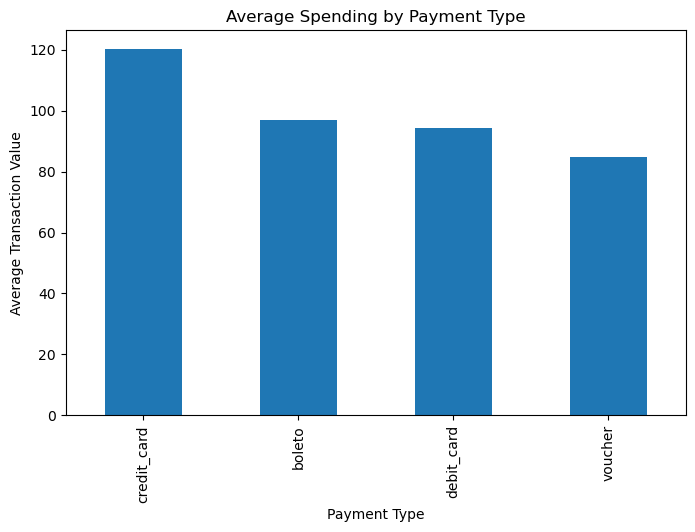

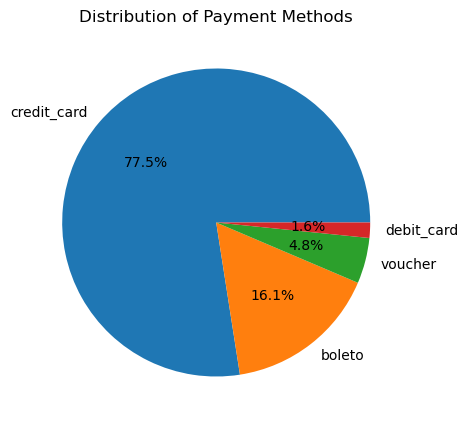

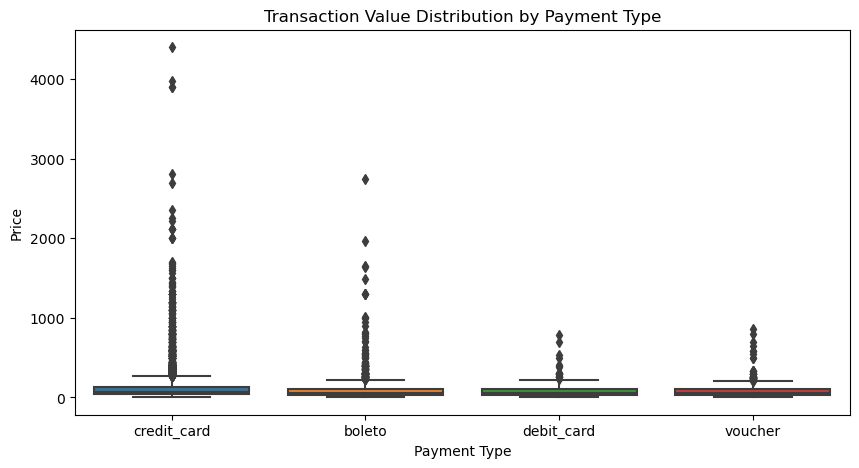

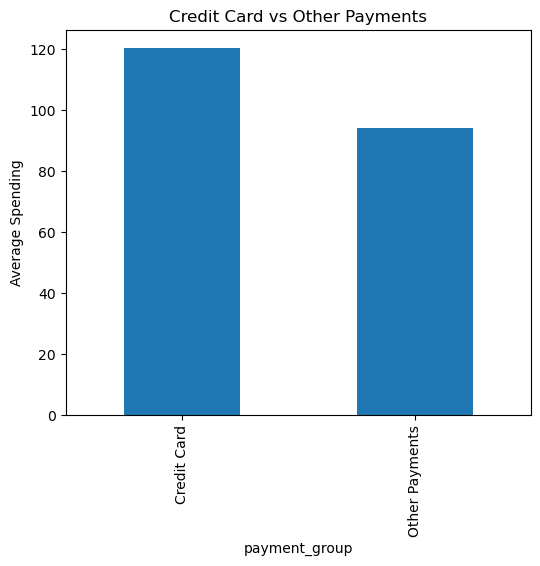

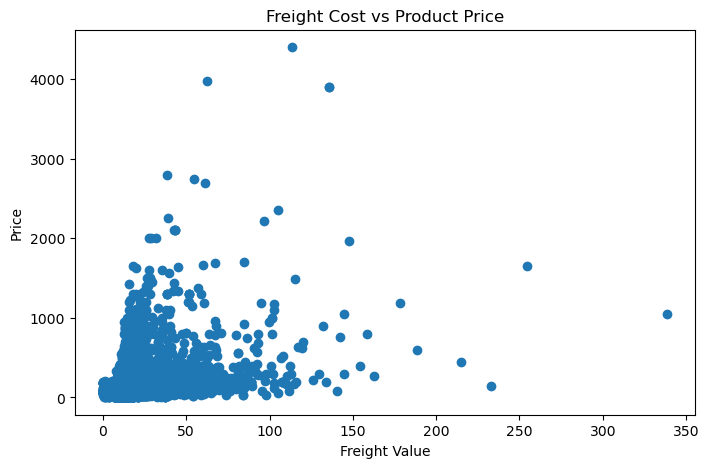

In [34]:
# VISUALIZATIONS



# Customers Paying via Credit Card Spend More
import matplotlib.pyplot as plt
import seaborn as sns

# 1. AVERAGE SPENDING BY PAYMENT TYPE
payment_avg = df.groupby(
    'payment_type'
)['price'].mean().sort_values(
    ascending=False
)
plt.figure(figsize=(8,5))
payment_avg.plot(kind='bar')
plt.title("Average Spending by Payment Type")
plt.xlabel("Payment Type")
plt.ylabel("Average Transaction Value")
plt.show()


# 2. PAYMENT TYPE DISTRIBUTION
payment_counts = df['payment_type'].value_counts()
plt.figure(figsize=(8,5))
payment_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title("Distribution of Payment Methods")
plt.ylabel("")
plt.show()


# 3. PRICE DISTRIBUTION BY PAYMENT TYPE
plt.figure(figsize=(10,5))
sns.boxplot(
    x='payment_type',
    y='price',
    data=df
)
plt.title("Transaction Value Distribution by Payment Type")
plt.xlabel("Payment Type")
plt.ylabel("Price")
plt.show()


# 4. CREDIT CARD VS OTHER PAYMENTS
df['payment_group'] = df['payment_type'].apply(

    lambda x:
    'Credit Card'
    if x == 'credit_card'
    else 'Other Payments'

)
group_avg = df.groupby(
    'payment_group'
)['price'].mean()
plt.figure(figsize=(6,5))
group_avg.plot(kind='bar')
plt.title("Credit Card vs Other Payments")
plt.ylabel("Average Spending")
plt.show()


# 5. FREIGHT COST VS PRICE
plt.figure(figsize=(8,5))

plt.scatter(
    df['freight_value'],
    df['price']
)
plt.title("Freight Cost vs Product Price")
plt.xlabel("Freight Value")
plt.ylabel("Price")
plt.show()

In [28]:

# HYPOTHESIS 2
# Customer Satisfaction Is Influenced by Regional Expectations

print("\n==============================")
print("HYPOTHESIS 2")
print("==============================\n")



# CREATE DELIVERY DAYS COLUMN
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])
df['delivery_days'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days

# REMOVE NEGATIVE DELIVERY DAYS
df = df[df['delivery_days'] >= 0]

# AVERAGE REVIEW SCORE BY STATE
print("\nAverage Review Score by State:\n")
print(df.groupby('customer_state')['review_score'].mean())

# ANOVA TEST
from scipy.stats import f_oneway
sp = df[df['customer_state'] == 'SP']['review_score']
rj = df[df['customer_state'] == 'RJ']['review_score']
mg = df[df['customer_state'] == 'MG']['review_score']
f_stat, p_value = f_oneway(sp, rj, mg)
print("\nANOVA RESULTS")
print("F-statistic:", f_stat)
print("P-value:", p_value)
if p_value < 0.05:
    print("Review scores differ significantly across states")
else:
    print("No significant difference found")

# SIMPLE REGRESSION
import statsmodels.formula.api as smf
model2 = smf.ols(
    'review_score ~ delivery_days + freight_value',
    data=df
).fit()
print("\nREGRESSION RESULTS")
print(model2.summary())

# FINAL INTERPRETATION
print("""INTERPRETATION:

Customer satisfaction appears to vary across regions.

Delivery speed alone does not fully explain
review behavior.

Regional expectations may influence how
customers rate their shopping experience.""")



HYPOTHESIS 2


Average Review Score by State:

customer_state
AC    2.500000
AL    3.739130
AM    4.272727
AP    3.250000
BA    3.438053
CE    3.312500
DF    3.883333
ES    3.934783
GO    3.776860
MA    2.860465
MG    4.223284
MS    3.774194
MT    3.424242
PA    3.480519
PB    3.566667
PE    4.212121
PI    3.944444
PR    4.248447
RJ    3.780899
RN    4.409091
RO    3.636364
RR    3.666667
RS    4.078385
SC    4.141914
SE    3.772727
SP    4.287827
TO    3.562500
Name: review_score, dtype: float64

ANOVA RESULTS
F-statistic: 83.98121714275679
P-value: 7.056103174972476e-37
Review scores differ significantly across states

REGRESSION RESULTS
                            OLS Regression Results                            
Dep. Variable:           review_score   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     43.88
Date:                Sun, 17 May 20

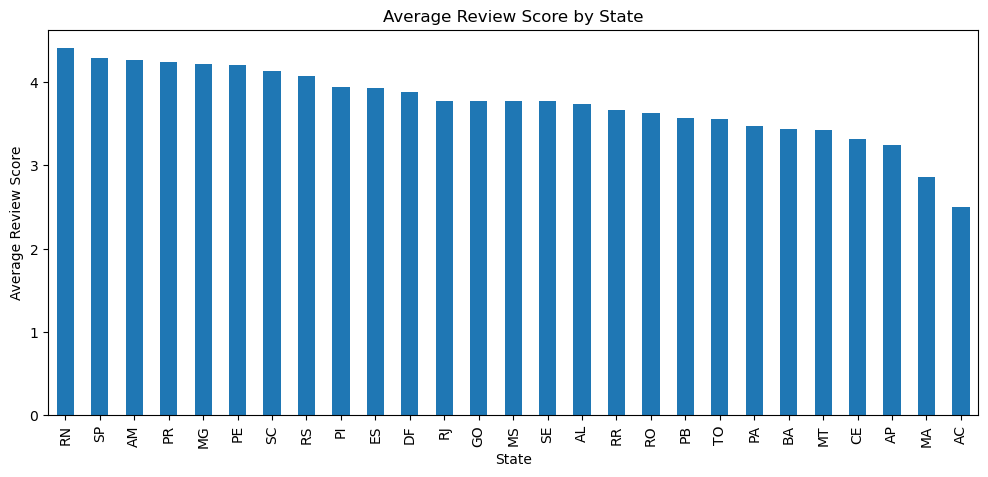

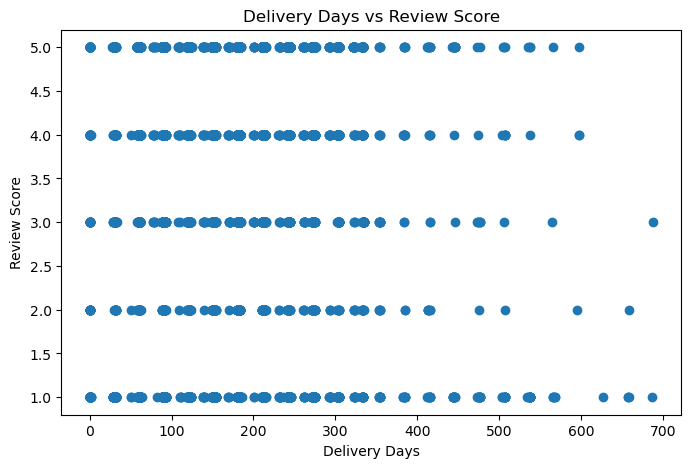

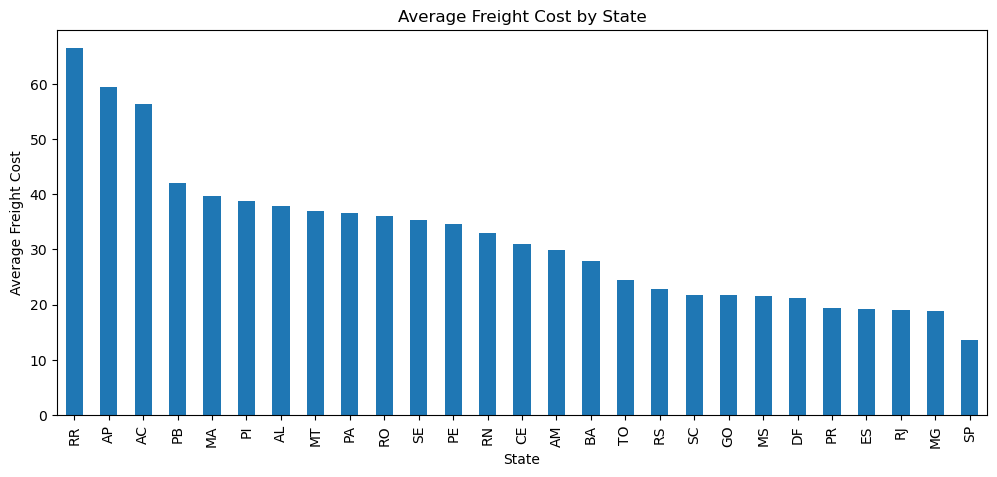

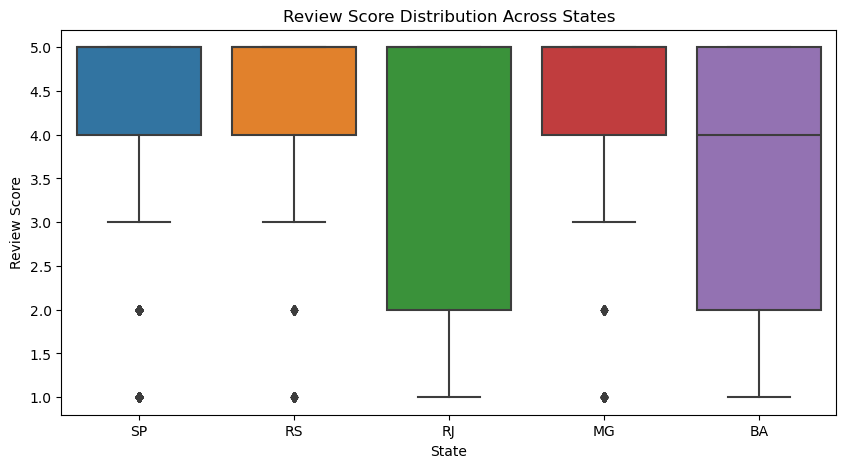

In [32]:
# VISUALIZATIONS 

# Average Review Score by State
state_reviews = df.groupby(
    'customer_state'
)['review_score'].mean().sort_values(
    ascending=False
)
plt.figure(figsize=(12,5))
state_reviews.plot(kind='bar')
plt.title("Average Review Score by State")
plt.xlabel("State")
plt.ylabel("Average Review Score")
plt.show()

# Delivery Days vs Review Score
plt.figure(figsize=(8,5))
plt.scatter(
    df['delivery_days'],
    df['review_score']
)
plt.title("Delivery Days vs Review Score")
plt.xlabel("Delivery Days")
plt.ylabel("Review Score")
plt.show()

# Average Freight Cost by State
freight_state = df.groupby(
    'customer_state'
)['freight_value'].mean().sort_values(
    ascending=False
)
plt.figure(figsize=(12,5))
freight_state.plot(kind='bar')
plt.title("Average Freight Cost by State")
plt.xlabel("State")
plt.ylabel("Average Freight Cost")
plt.show()

# Boxplot of Review Scores Across States (BEST ONE)
import seaborn as sns
top_states = ['SP', 'RJ', 'MG', 'BA', 'RS']
filtered_df = df[
    df['customer_state'].isin(top_states)]
plt.figure(figsize=(10,5))
sns.boxplot(
    x='customer_state',
    y='review_score',
    data=filtered_df
)
plt.title("Review Score Distribution Across States")
plt.xlabel("State")
plt.ylabel("Review Score")
plt.show()